In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsmodels.tsa.seasonal import STL

from scipy import stats
from scipy import optimize
import seaborn as sns;

import statsmodels.api as sm

import time

from scipy.optimize import curve_fit

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler

In [2]:
# Load MIRA data
mira_cleaned = pd.read_csv('.../.mira_cleaned_get.csv')

[1 2 4 6 5 3]
Index(['id_hh', 'year', 'month', 'day', 'Maize', 'Sorghum', 'Millet', 'Rice',
       'CassavaRoot', 'CassavaLeaves', 'SweetPotato', 'OtherTubers', 'Peanuts',
       'Cowpeas', 'Beans', 'Dolique', 'OtherLegumues', 'item_14',
       'green_whiteCactus', 'redCactus', 'vegetables', 'melons', 'otherFruit',
       'cactusLeaves', 'otherLeaves', 'beef', 'otherMeat', 'milkProducts',
       'item25', 'watermelon', 'peas', 'fishProducts', 'other', 'eggs',
       'sugar', 'serial_date', 'lat', 'lon', 'commune', 'household_ndvi',
       'YearMonth'],
      dtype='object')


In [3]:
#Load NDVI Data 

In [4]:
# Perform SVD
# Select foods categorized as crops 
food_columns = ['Maize', 'Sorghum', 'Millet', 'Rice',
       'CassavaRoot', 'CassavaLeaves', 'SweetPotato', 'OtherTubers', 'Peanuts',
       'Cowpeas', 'Beans', 'Dolique', 'OtherLegumues',
       'green_whiteCactus', 'redCactus', 'vegetables', 'melons', 'otherFruit',
       'cactusLeaves', 'otherLeaves', 'watermelon', 'peas']

# Impute column mean by commune for missing data
mira_cleaned[food_columns] = (
    mira_cleaned.groupby('commune')[food_columns]
      .transform(lambda x: x.fillna(x.mean()))
)

       Maize  Sorghum  Millet  Rice  CassavaRoot  CassavaLeaves  SweetPotato  \
0        0.0      0.0     0.0   0.0          0.0            0.0          0.0   
1        1.0      0.0     0.0   0.0          1.0            0.0          0.0   
2        1.0      0.0     0.0   0.0          0.0            0.0          0.0   
3        1.0      0.0     0.0   0.0          0.0            0.0          0.0   
4        0.0      1.0     0.0   0.0          0.0            0.0          0.0   
...      ...      ...     ...   ...          ...            ...          ...   
21148    1.0      0.0     0.0   0.0          0.0            0.0          0.0   
21149    0.0      0.0     0.0   0.0          0.0            0.0          0.0   
21150    0.0      0.0     0.0   0.0          0.0            0.0          0.0   
21151    0.0      0.0     0.0   0.0          0.0            1.0          0.0   
21152    0.0      0.0     0.0   0.0          0.0            0.0          0.0   

       OtherTubers  Peanuts  Cowpeas  .

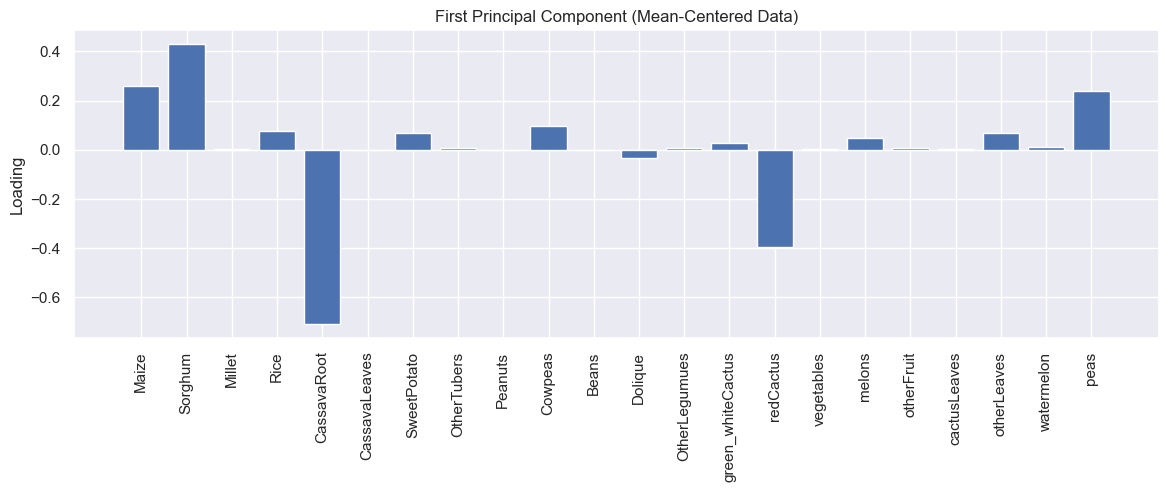

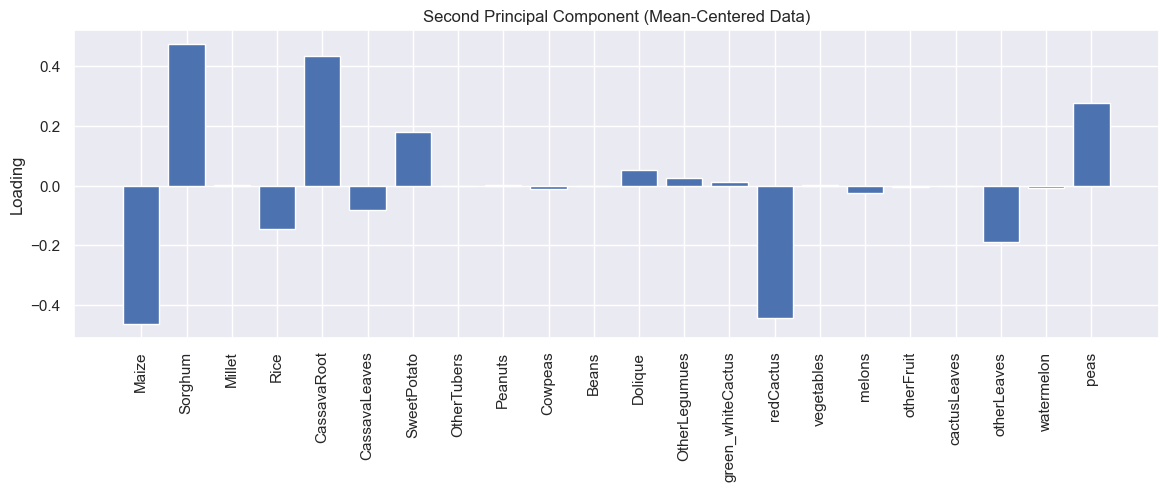

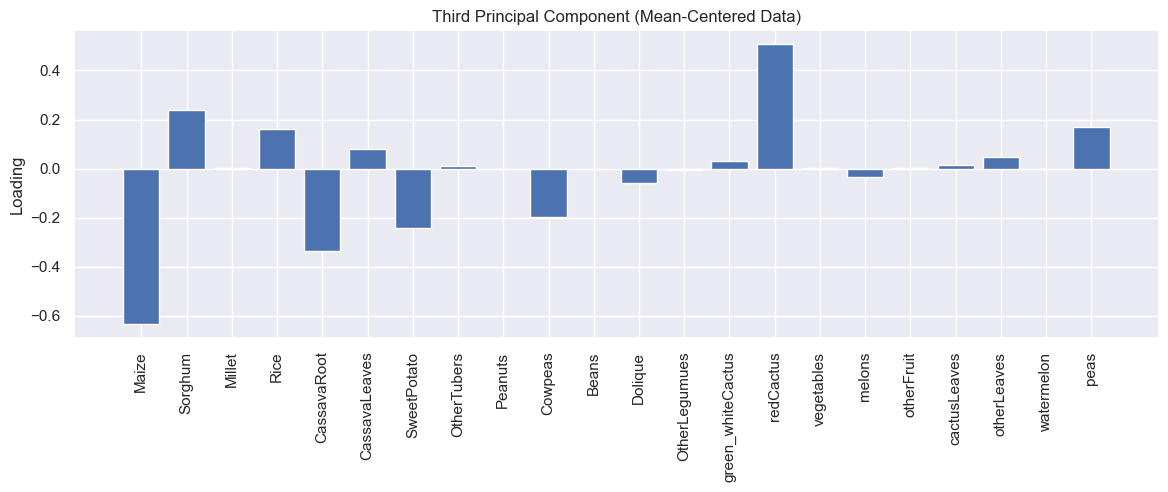

In [6]:
# Create a new df with just the NDVI values for each food
ndvi_foods = mira_cleaned[food_columns]
print(ndvi_foods)

# Mean centering
ndvi_foods_centered = (
    mira_cleaned
    .groupby('commune')[food_columns]
    .transform(lambda x: x - x.mean())
)


# Perform SVD on the mean-centered data
U, Sigma, VT = np.linalg.svd(ndvi_foods_centered, full_matrices=False)

########## Plot the first three principal components ############
# Plot the first principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[0, :])  # First pc
plt.title('First Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

# Plot the second principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[1, :])  # Second pc
plt.title('Second Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

# Plot the third principal component
plt.figure(figsize=[14,4])
plt.bar(food_columns, VT[2, :])  # Third pc
plt.title('Third Principal Component (Mean-Centered Data)')
plt.xticks(rotation=90)
plt.ylabel('Loading')
plt.grid(True)
plt.show()

In [7]:
######## Analysis of NDVI v PC1 ############
# Project 1st pc back onto the data
pc1 = VT[0, :]

projected_data = np.dot(ndvi_foods_centered, pc1)

# Add back to MIRA data
mira_cleaned['dc1'] = projected_data

# Print the Variance Explained
total_variance = np.sum(Sigma**2)  # Sum of squares of all singular values
variance_explained_first_PCA = (Sigma[0]**2) / total_variance  # Proportion for the first singular value

print("Variance explained by the first principal component: {:.2f}%".format(variance_explained_first_PCA * 100))


Variance explained by the first principal component: 17.78%


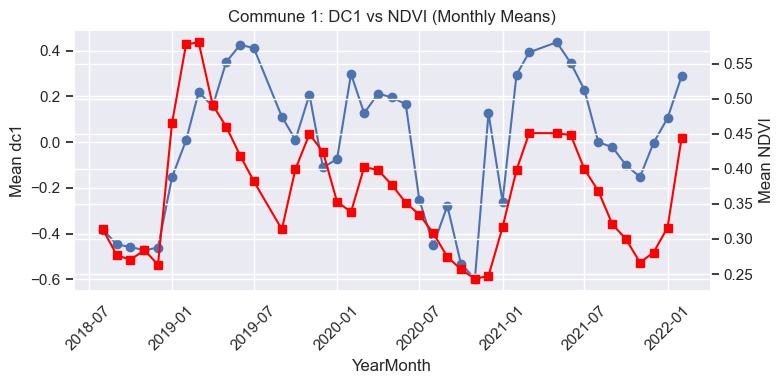

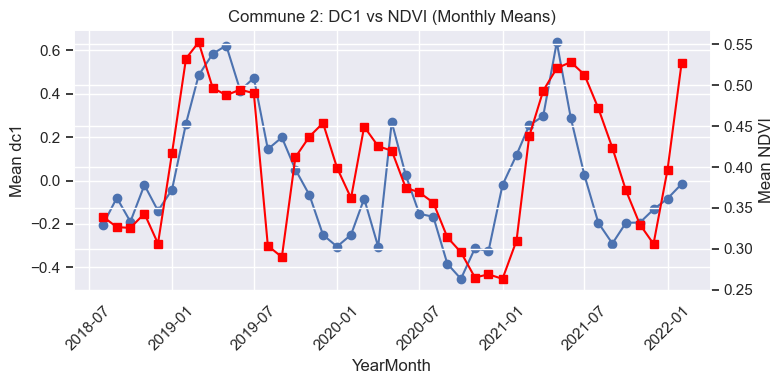

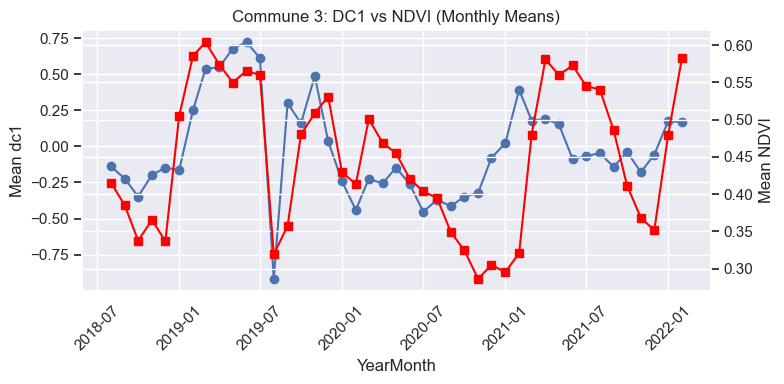

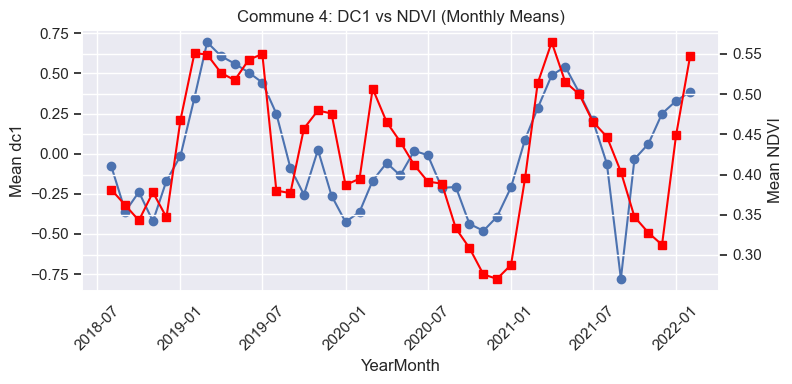

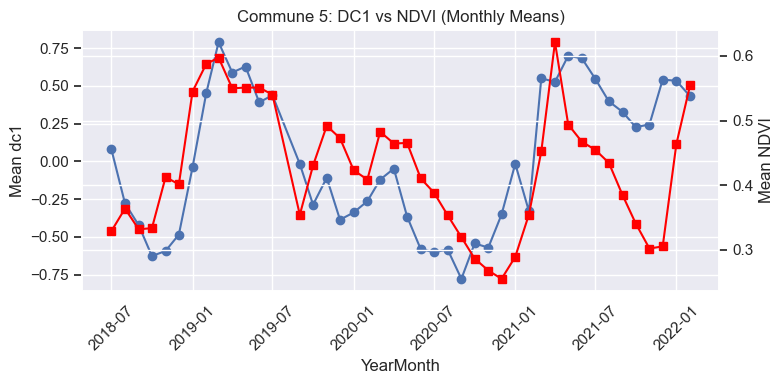

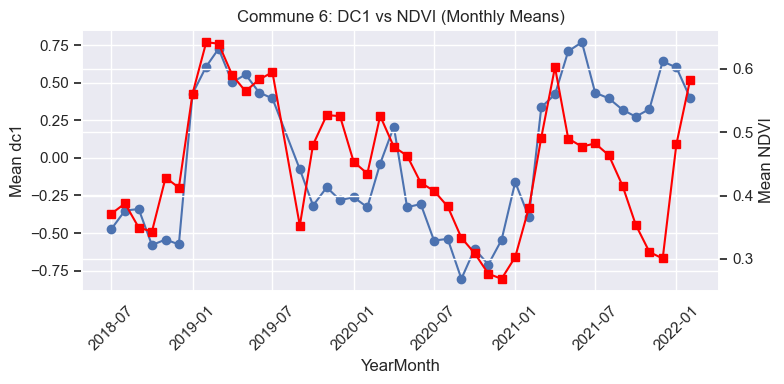

In [9]:
# Plt commune avg ndvi vs commune avg DC1 

df_avg = (
    mira_cleaned
    .groupby(['commune', 'YearMonth'])
    .agg(
        dc1_mean = ('dc1', 'mean'),
        ndvi_mean = ('ndvi', 'mean')
    )
    .reset_index()
)

df_subset = df_avg[df_avg['commune'].isin([1,2,3,4,5,6])]


communes = [1, 2, 3, 4, 5, 6]

for c in communes:
    sub = df_subset[df_subset['commune'] == c]

    fig, ax1 = plt.subplots(figsize=(8,4))

    # Left axis → dc1
    ax1.plot(sub['YearMonth'], sub['dc1_mean'], label='dc1 (mean)', marker='o')
    ax1.set_ylabel('Mean dc1')
    ax1.set_xlabel('YearMonth')
    ax1.tick_params(axis='x', rotation=45)

    # Right axis → NDVI
    ax2 = ax1.twinx()
    ax2.plot(sub['YearMonth'], sub['ndvi_mean'], color='red',
             label='NDVI (mean)', marker='s')
    ax2.set_ylabel('Mean NDVI')

    plt.title(f'Commune {c}: DC1 vs NDVI (Monthly Means)')
    plt.tight_layout()
    plt.show()


In [10]:
# Get correlations for each commune
corrs = (
    df_avg
    .groupby('commune')
    .apply(lambda g: g['dc1_mean'].corr(g['ndvi_mean']))
)


corrs_1_to_6 = corrs.loc[[1,2,3,4,5,6]]
print(corrs_1_to_6)

commune
1    0.635602
2    0.611593
3    0.588414
4    0.699037
5    0.578130
6    0.610432
dtype: float64


/var/folders/zj/s5ntb465025_l6d7576q4jsw0000gn/T/ipykernel_84334/892679856.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['dc1_mean'].corr(g['ndvi_mean']))
